Loaded checkpoint from step 90000
Running truth + free drift + EnKPF from checkpoint...
[assim @ step 90100] forecast obs misfit = 5.2969e+01 | analysis obs misfit = 5.1976e+01 | forecast state err = 1.7410e-02 | analysis state err = 1.9789e-02 | gamma = 0.458 | ESS = 8.00/10 | resampled = False
[assim @ step 90200] forecast obs misfit = 7.6486e+01 | analysis obs misfit = 7.2754e+01 | forecast state err = 1.3607e-02 | analysis state err = 2.6822e-02 | gamma = 0.200 | ESS = 8.00/10 | resampled = True
[assim @ step 90300] forecast obs misfit = 6.9166e+01 | analysis obs misfit = 6.8405e+01 | forecast state err = 2.1622e-02 | analysis state err = 2.1180e-02 | gamma = 0.621 | ESS = 8.00/10 | resampled = True
[assim @ step 90400] forecast obs misfit = 5.6528e+01 | analysis obs misfit = 5.6528e+01 | forecast state err = 1.8929e-02 | analysis state err = 1.8929e-02 | gamma = 1.000 | ESS = 8.37/10 | resampled = False
[assim @ step 90500] forecast obs misfit = 7.4342e+01 | analysis obs misfit = 

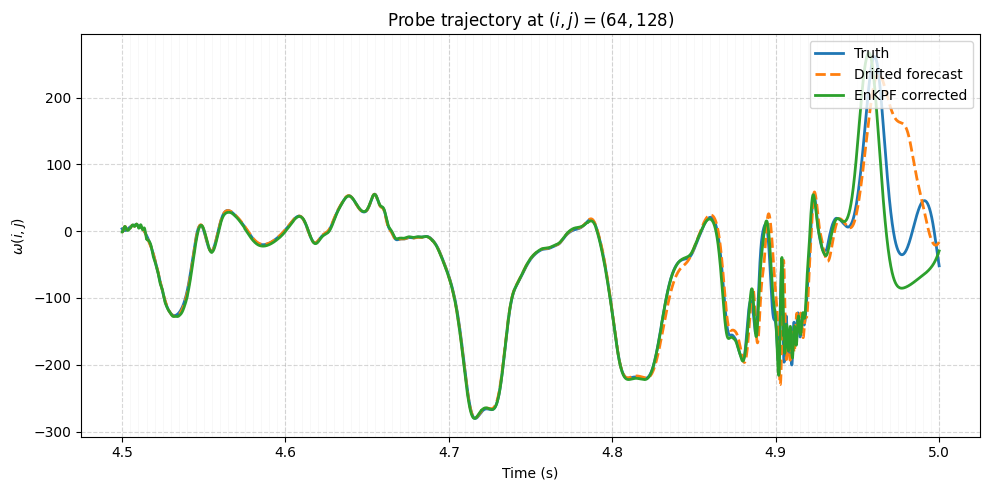

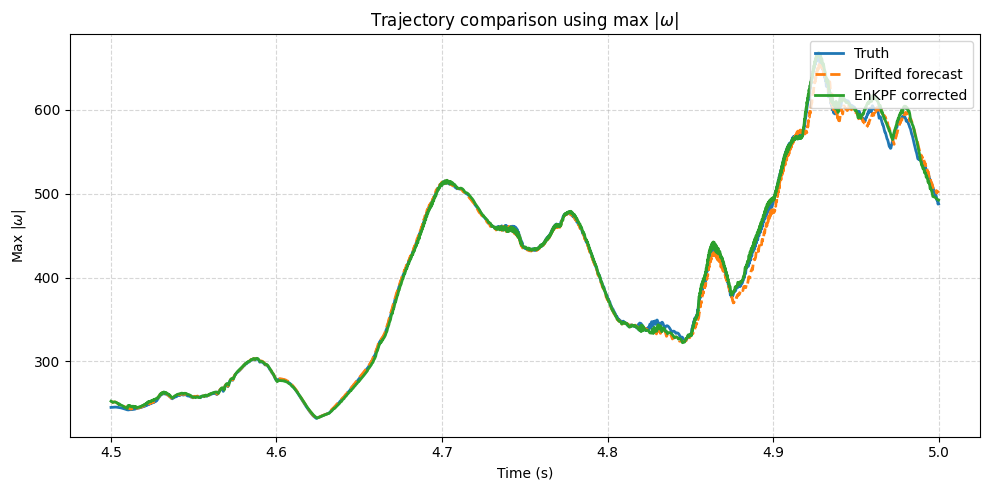

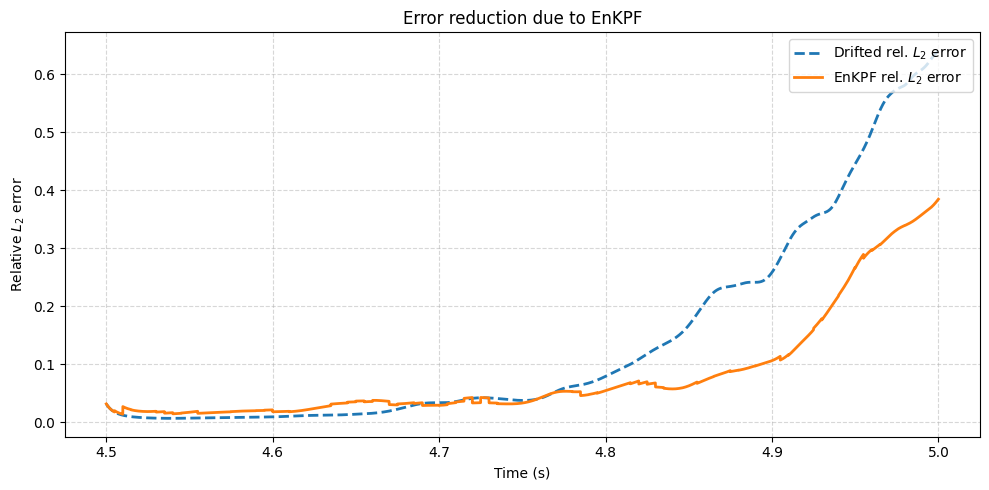

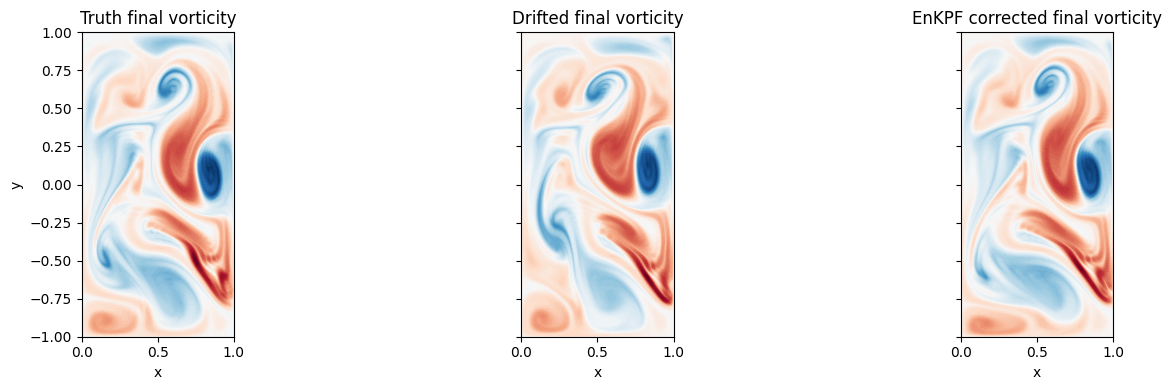

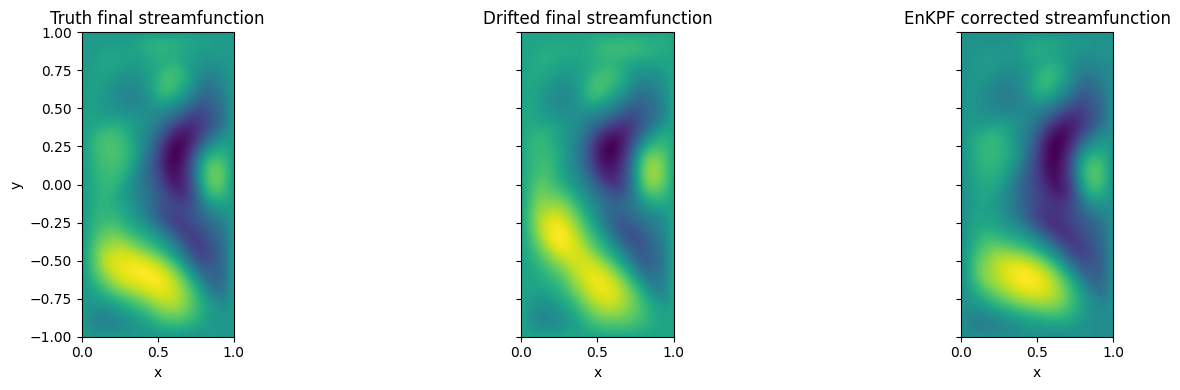

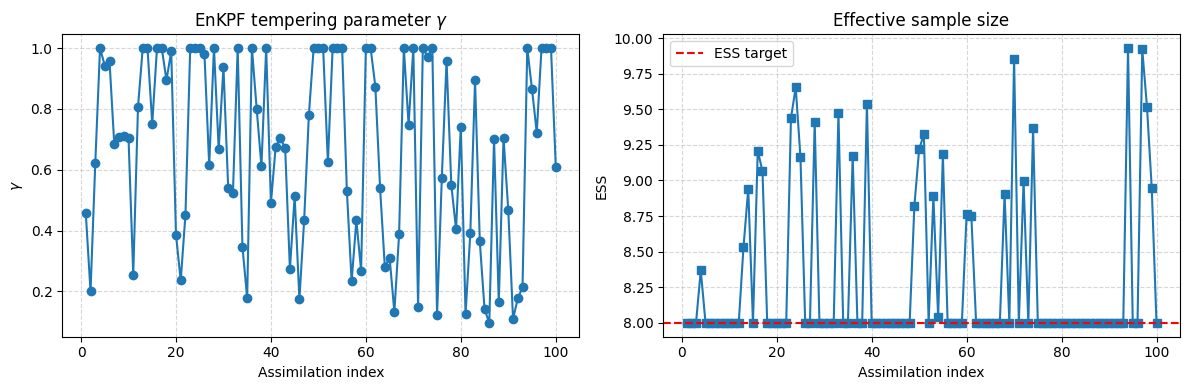

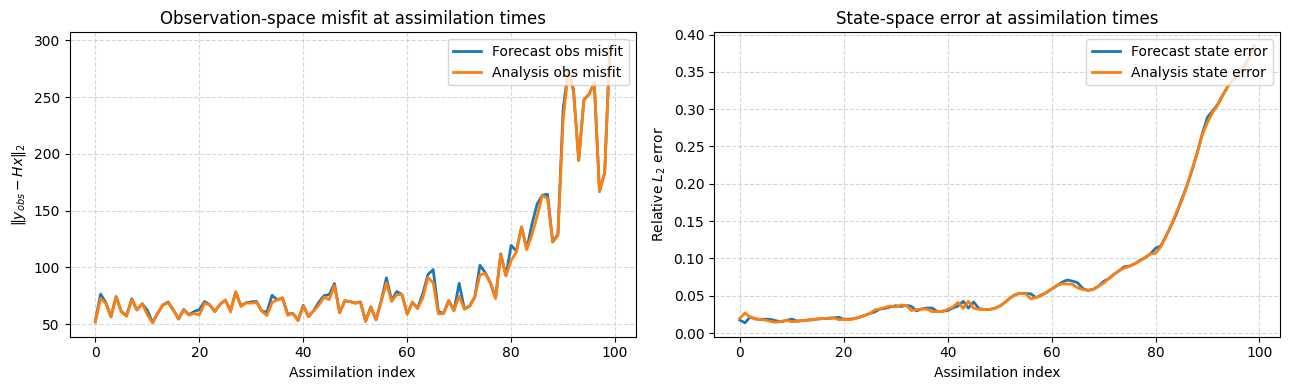

In [1]:
#!/usr/bin/env python3
# -*- coding: utf-8 -*-

import os
import numpy as np
import matplotlib.pyplot as plt
import time as tm
from numba import njit
from scipy.fft import dst, idst
from scipy.special import logsumexp

# ============================================================
# USER SETTINGS
# ============================================================
checkpoint_step = 90000
checkpoint_file = f"qg_truth_checkpoint_step_{checkpoint_step}.npz"

assim_config = {
    "ensemble_size": 10,
    "obs_interval": 100,
    "obs_noise_std": 0.1,
    "init_perturb_std": 0.10,
    "inflation": 1.02,
    "num_obs": 36,
    "forecast_steps_after_checkpoint": 10000,
    "random_seed": 42,

    # ---- EnKPF-specific settings ----
    "ess_target_fraction": 0.8,
    "gamma_search_iters": 25,
    "gamma_tol": 1e-4,
    "jitter_after_resample": 0.00,
}

np.random.seed(assim_config["random_seed"])

# ============================================================
# LOAD CHECKPOINT
# ============================================================
if not os.path.exists(checkpoint_file):
    raise FileNotFoundError(
        f"Checkpoint file '{checkpoint_file}' not found. "
        f"Run the truth script first."
    )

data = np.load(checkpoint_file)

wen_truth = data["wen"].copy()
sen_truth = data["sen"].copy()
start_step = int(data["step"])

config = {
    "NX": int(data["NX"]),
    "NY": int(data["NY"]),
    "Re": float(data["Re"]),
    "Ro": float(data["Ro"]),
    "dt": float(data["dt"]),
    "LX": float(data["LX"]),
    "LY": float(data["LY"]),
}

dx = float(data["dx"])
dy = float(data["dy"])
dt = config["dt"]

nx = config["NX"]
ny = config["NY"]

nxi = nx - 1
nyi = ny - 1
state_dim = nxi * nyi

nt_assim = assim_config["forecast_steps_after_checkpoint"]

print(f"Loaded checkpoint from step {start_step}")

# ============================================================
# NUMERICAL ROUTINES
# ============================================================
@njit
def compute_physics_cfl(nx, ny, dx, dy, dt, s):
    u_vel = (s[1:nx, 2:ny+1] - s[1:nx, 0:ny-1]) / (2.0 * dy)
    v_vel = -(s[2:nx+1, 1:ny] - s[0:nx-1, 1:ny]) / (2.0 * dx)
    max_u = np.max(np.abs(u_vel))
    max_v = np.max(np.abs(v_vel))
    return dt * max(max_u/dx, max_v/dy)


def fst_poisson_2d(nx, ny, dx, dy, f):
    f_interior = f[1:nx, 1:ny]
    ft = idst(idst(f_interior, axis=0, type=1), axis=1, type=1)

    i = np.arange(1, nx).reshape(-1, 1)
    j = np.arange(1, ny)

    eigen_x = 2.0 / (dx**2) * (np.cos(np.pi * i / nx) - 1.0)
    eigen_y = 2.0 / (dy**2) * (np.cos(np.pi * j / ny) - 1.0)

    u_coeff = ft / (eigen_x + eigen_y)

    u_interior = dst(dst(u_coeff, axis=0, type=1), axis=1, type=1)
    u = np.zeros((nx + 1, ny + 1))
    u[1:nx, 1:ny] = u_interior
    return u


@njit
def rhs_arakawa(nx, ny, dx, dy, re, ro, w, s, fs):
    gg = 1.0 / (4.0 * dx * dy)
    hh = 1.0 / 3.0

    j1 = gg * ((w[2:nx+1, 1:ny] - w[0:nx-1, 1:ny]) * (s[1:nx, 2:ny+1] - s[1:nx, 0:ny-1]) -
               (w[1:nx, 2:ny+1] - w[1:nx, 0:ny-1]) * (s[2:nx+1, 1:ny] - s[0:nx-1, 1:ny]))

    j2 = gg * (w[2:nx+1, 1:ny] * (s[2:nx+1, 2:ny+1] - s[2:nx+1, 0:ny-1]) -
               w[0:nx-1, 1:ny] * (s[0:nx-1, 2:ny+1] - s[0:nx-1, 0:ny-1]) -
               w[1:nx, 2:ny+1] * (s[2:nx+1, 2:ny+1] - s[0:nx-1, 2:ny+1]) +
               w[1:nx, 0:ny-1] * (s[2:nx+1, 0:ny-1] - s[0:nx-1, 0:ny-1]))

    j3 = gg * (w[2:nx+1, 2:ny+1] * (s[1:nx, 2:ny+1] - s[2:nx+1, 1:ny]) -
               w[0:nx-1, 0:ny-1] * (s[0:nx-1, 1:ny] - s[1:nx, 0:ny-1]) -
               w[0:nx-1, 2:ny+1] * (s[1:nx, 2:ny+1] - s[0:nx-1, 1:ny]) +
               w[2:nx+1, 0:ny-1] * (s[2:nx+1, 1:ny] - s[1:nx, 0:ny-1]))

    jac = (j1 + j2 + j3) * hh

    lap = (1.0/dx**2) * (w[2:nx+1, 1:ny] - 2*w[1:nx, 1:ny] + w[0:nx-1, 1:ny]) + \
          (1.0/dy**2) * (w[1:nx, 2:ny+1] - 2*w[1:nx, 1:ny] + w[1:nx, 0:ny-1])

    cor = (1.0/(2.0*dx)) * (s[2:nx+1, 1:ny] - s[0:nx-1, 1:ny])

    rhs = np.zeros((nx + 1, ny + 1))
    rhs[1:nx, 1:ny] = -jac + lap/re + fs[1:nx, 1:ny] + cor/ro
    return rhs


def rk3_step(wen, sen, fs, config, dx, dy, dt):
    nx = config["NX"]
    ny = config["NY"]
    re = config["Re"]
    ro = config["Ro"]

    r1 = rhs_arakawa(nx, ny, dx, dy, re, ro, wen, sen, fs)
    t1 = wen + dt * r1
    s1 = fst_poisson_2d(nx, ny, dx, dy, t1)

    r2 = rhs_arakawa(nx, ny, dx, dy, re, ro, t1, s1, fs)
    t2 = 0.75 * wen + 0.25 * t1 + 0.25 * dt * r2
    s2 = fst_poisson_2d(nx, ny, dx, dy, t2)

    r3 = rhs_arakawa(nx, ny, dx, dy, re, ro, t2, s2, fs)
    wen_new = (1.0/3.0) * wen + (2.0/3.0) * t2 + (2.0/3.0) * dt * r3
    sen_new = fst_poisson_2d(nx, ny, dx, dy, wen_new)

    return wen_new, sen_new

# ============================================================
# STATE / OBSERVATION HELPERS
# ============================================================
def interior_to_state(w):
    return w[1:nx, 1:ny].reshape(-1).copy()


def state_to_full_w(x):
    w = np.zeros((nx + 1, ny + 1))
    w[1:nx, 1:ny] = x.reshape(nxi, nyi)
    return w


def build_observation_indices(nx, ny, num_obs):
    nside = int(np.ceil(np.sqrt(num_obs)))
    xs = np.linspace(4, nx - 4, nside, dtype=int)
    ys = np.linspace(4, ny - 4, nside, dtype=int)

    pairs = []
    for i in xs:
        for j in ys:
            if 1 <= i <= nx - 1 and 1 <= j <= ny - 1:
                pairs.append((i, j))
    pairs = pairs[:num_obs]

    obs_idx = []
    for i, j in pairs:
        flat_idx = (i - 1) * (ny - 1) + (j - 1)
        obs_idx.append(flat_idx)

    return np.array(obs_idx, dtype=int), pairs


def observe_linear(x, obs_idx):
    return x[obs_idx]


def rel_l2(a, b):
    return np.linalg.norm(a - b) / (np.linalg.norm(a) + 1e-12)

# ============================================================
# ENKPF HELPERS
# ============================================================
def systematic_resample_indices(weights):
    Ne = len(weights)
    positions = (np.arange(Ne) + np.random.rand()) / Ne
    cumsum = np.cumsum(weights)
    cumsum[-1] = 1.0
    return np.searchsorted(cumsum, positions)


def effective_sample_size(weights):
    return 1.0 / np.sum(weights**2)


def compute_tempered_weights(Yf, y_obs, R_inv, gamma):
    """
    Yf    : (m, Ne)
    y_obs : (m,)
    R_inv : (m, m)
    gamma : scalar in [0, 1]
    """
    Ne = Yf.shape[1]
    logw = np.zeros(Ne)

    for e in range(Ne):
        innov = y_obs - Yf[:, e]
        logw[e] = -0.5 * gamma * (innov.T @ R_inv @ innov)

    logw -= logsumexp(logw)
    return np.exp(logw)


def choose_gamma_bisect(Yf, y_obs, R_inv, ess_target, nit=25, tol=1e-4):
    """
    Find gamma in [0,1] so ESS(weights(gamma)) ~= ess_target.
    If gamma=1 still gives ESS >= target, return 1.
    """
    w_full = compute_tempered_weights(Yf, y_obs, R_inv, gamma=1.0)
    ess_full = effective_sample_size(w_full)

    if ess_full >= ess_target:
        return 1.0

    lo, hi = 0.0, 1.0
    for _ in range(nit):
        mid = 0.5 * (lo + hi)
        w_mid = compute_tempered_weights(Yf, y_obs, R_inv, gamma=mid)
        ess_mid = effective_sample_size(w_mid)

        if ess_mid < ess_target:
            hi = mid
        else:
            lo = mid

        if hi - lo < tol:
            break

    return 0.5 * (lo + hi)


def enkpf_analysis(Xf, y_obs, obs_idx, R, inflation=1.0,
                   ess_target_fraction=0.8,
                   gamma_search_iters=25,
                   gamma_tol=1e-4,
                   jitter_after_resample=0.0):
    """
    EnKPF update:
      1) inflate prior ensemble
      2) particle stage with tempered likelihood gamma
      3) resample only if ESS < target
      4) EnKF-style correction with residual likelihood (1-gamma)

    Xf:    (n, Ne)
    y_obs: (m,)
    obs_idx: observed state indices
    R:     (m, m)
    """
    n, Ne = Xf.shape
    m = len(obs_idx)

    # --------------------------------------------------------
    # prior inflation
    # --------------------------------------------------------
    xf_bar = np.mean(Xf, axis=1, keepdims=True)
    Af = Xf - xf_bar
    Xf_inf = xf_bar + inflation * Af

    # --------------------------------------------------------
    # forecasted observations
    # --------------------------------------------------------
    Yf = Xf_inf[obs_idx, :]
    R_inv = np.linalg.inv(R)

    # --------------------------------------------------------
    # choose gamma so ESS tracks target
    # --------------------------------------------------------
    ess_target = ess_target_fraction * Ne
    gamma = choose_gamma_bisect(
        Yf, y_obs, R_inv,
        ess_target=ess_target,
        nit=gamma_search_iters,
        tol=gamma_tol
    )

    # --------------------------------------------------------
    # particle stage
    # --------------------------------------------------------
    if gamma > 1e-12:
        w = compute_tempered_weights(Yf, y_obs, R_inv, gamma)
        ess = effective_sample_size(w)

        if ess < ess_target:
            res_idx = systematic_resample_indices(w)
            Xp = Xf_inf[:, res_idx].copy()
            resampled = True
        else:
            Xp = Xf_inf.copy()
            resampled = False
    else:
        w = np.ones(Ne) / Ne
        ess = Ne
        Xp = Xf_inf.copy()
        resampled = False

    # --------------------------------------------------------
    # optional rejuvenation
    # --------------------------------------------------------
    if jitter_after_resample > 0.0 and resampled:
        xp_bar = np.mean(Xp, axis=1, keepdims=True)
        Ap = Xp - xp_bar
        state_std = np.std(Ap, axis=1, keepdims=True) + 1e-12
        Xp += jitter_after_resample * state_std * np.random.randn(n, Ne)

    # --------------------------------------------------------
    # residual Gaussian update with remaining likelihood
    # --------------------------------------------------------
    gamma_c = min(gamma, 1.0 - 1e-8)
    residual_factor = max(1.0 - gamma_c, 1e-8)
    R_resid = R / residual_factor

    xp_bar = np.mean(Xp, axis=1, keepdims=True)
    Ap = Xp - xp_bar

    Yp = Xp[obs_idx, :]
    yp_bar = np.mean(Yp, axis=1, keepdims=True)
    Dp = Yp - yp_bar

    PHT = (Ap @ Dp.T) / (Ne - 1)
    S = (Dp @ Dp.T) / (Ne - 1) + R_resid
    K = PHT @ np.linalg.inv(S)

    Xa = np.zeros_like(Xp)
    cholR = np.linalg.cholesky(R_resid)

    for e in range(Ne):
        y_pert = y_obs + cholR @ np.random.randn(m)
        Xa[:, e] = Xp[:, e] + K @ (y_pert - Yp[:, e])

    stats = {
        "gamma": gamma,
        "ess": ess,
        "ess_target": ess_target,
        "resampled": resampled,
    }

    return Xa, stats

# ============================================================
# GRID / FORCING
# ============================================================
x_grid = np.linspace(0.0, config["LX"], config["NX"] + 1)
y_grid = np.linspace(-0.5 * config["LY"], 0.5 * config["LY"], config["NY"] + 1)
X, Y = np.meshgrid(x_grid, y_grid, indexing='ij')

fs = np.zeros((nx + 1, ny + 1))
fs[1:-1, 1:-1] = (1.0 / config["Ro"]) * np.sin(np.pi * Y[1:-1, 1:-1])

# ============================================================
# ENKPF INITIALIZATION
# ============================================================
Ne = assim_config["ensemble_size"]
obs_interval = assim_config["obs_interval"]
obs_noise_std = assim_config["obs_noise_std"]
init_perturb_std = assim_config["init_perturb_std"]
inflation = assim_config["inflation"]
num_obs = assim_config["num_obs"]

ess_target_fraction = assim_config["ess_target_fraction"]
gamma_search_iters = assim_config["gamma_search_iters"]
gamma_tol = assim_config["gamma_tol"]
jitter_after_resample = assim_config["jitter_after_resample"]

x_truth0 = interior_to_state(wen_truth)
truth_scale = np.sqrt(np.mean(x_truth0**2))

obs_idx, obs_pairs = build_observation_indices(nx, ny, num_obs)
m = len(obs_idx)
R = (obs_noise_std * truth_scale) ** 2 * np.eye(m)

ensemble_w = []
ensemble_s = []

for e in range(Ne):
    pert = init_perturb_std * truth_scale * np.random.randn(state_dim)
    x0 = x_truth0 + pert
    w0 = state_to_full_w(x0)
    s0 = fst_poisson_2d(nx, ny, dx, dy, w0)
    ensemble_w.append(w0)
    ensemble_s.append(s0)

ensemble_w = np.array(ensemble_w)
ensemble_s = np.array(ensemble_s)

# free drift from ensemble mean
x_free = np.mean(np.array([interior_to_state(w) for w in ensemble_w]), axis=0)
free_w = state_to_full_w(x_free)
free_s = fst_poisson_2d(nx, ny, dx, dy, free_w)

# ============================================================
# DIAGNOSTIC STORAGE
# ============================================================
probe_i = nx // 2
probe_j = ny // 2

t_hist = []
truth_probe = []
drift_probe = []
analysis_probe = []

truth_max = []
drift_max = []
analysis_max = []

drift_err = []
analysis_err = []

assim_times = []
gamma_hist = []
ess_hist = []
resampled_hist = []

forecast_obs_misfit_hist = []
analysis_obs_misfit_hist = []

forecast_state_err_hist = []
analysis_state_err_hist = []

# ============================================================
# MAIN ASSIMILATION RUN
# ============================================================
clock_start = tm.time()
print("Running truth + free drift + EnKPF from checkpoint...")

for n in range(nt_assim):
    step = start_step + n + 1

    # --------------------------------------------------------
    # propagate truth
    # --------------------------------------------------------
    wen_truth, sen_truth = rk3_step(wen_truth, sen_truth, fs, config, dx, dy, dt)

    # --------------------------------------------------------
    # propagate free drift
    # --------------------------------------------------------
    free_w, free_s = rk3_step(free_w, free_s, fs, config, dx, dy, dt)

    # --------------------------------------------------------
    # ensemble forecast
    # --------------------------------------------------------
    for e in range(Ne):
        ensemble_w[e], ensemble_s[e] = rk3_step(
            ensemble_w[e], ensemble_s[e], fs, config, dx, dy, dt
        )

    # --------------------------------------------------------
    # assimilation at correct interval
    # --------------------------------------------------------
    if ((n + 1) % obs_interval) == 0:
        x_truth = interior_to_state(wen_truth)
        y_true = observe_linear(x_truth, obs_idx)
        y_obs = y_true + np.sqrt(np.diag(R)) * np.random.randn(m)

        Xf = np.zeros((state_dim, Ne))
        for e in range(Ne):
            Xf[:, e] = interior_to_state(ensemble_w[e])

        # forecast diagnostics before analysis
        xf_mean = np.mean(Xf, axis=1)
        yf_mean = observe_linear(xf_mean, obs_idx)

        forecast_obs_misfit = np.linalg.norm(y_obs - yf_mean)
        forecast_state_err = rel_l2(x_truth, xf_mean)

        Xa, stats = enkpf_analysis(
            Xf, y_obs, obs_idx, R,
            inflation=inflation,
            ess_target_fraction=ess_target_fraction,
            gamma_search_iters=gamma_search_iters,
            gamma_tol=gamma_tol,
            jitter_after_resample=jitter_after_resample
        )

        # analysis diagnostics after update
        xa_mean = np.mean(Xa, axis=1)
        ya_mean = observe_linear(xa_mean, obs_idx)

        analysis_obs_misfit = np.linalg.norm(y_obs - ya_mean)
        analysis_state_err = rel_l2(x_truth, xa_mean)

        # overwrite ensemble with analysis
        for e in range(Ne):
            ensemble_w[e] = state_to_full_w(Xa[:, e])
            ensemble_s[e] = fst_poisson_2d(nx, ny, dx, dy, ensemble_w[e])

        # store stats
        assim_times.append(step * dt)
        gamma_hist.append(stats["gamma"])
        ess_hist.append(stats["ess"])
        resampled_hist.append(int(stats["resampled"]))

        forecast_obs_misfit_hist.append(forecast_obs_misfit)
        analysis_obs_misfit_hist.append(analysis_obs_misfit)

        forecast_state_err_hist.append(forecast_state_err)
        analysis_state_err_hist.append(analysis_state_err)

        print(
            f"[assim @ step {step}] "
            f"forecast obs misfit = {forecast_obs_misfit:.4e} | "
            f"analysis obs misfit = {analysis_obs_misfit:.4e} | "
            f"forecast state err = {forecast_state_err:.4e} | "
            f"analysis state err = {analysis_state_err:.4e} | "
            f"gamma = {stats['gamma']:.3f} | "
            f"ESS = {stats['ess']:.2f}/{Ne} | "
            f"resampled = {stats['resampled']}"
        )

    # --------------------------------------------------------
    # diagnostics each step
    # --------------------------------------------------------
    w_mean = np.mean(ensemble_w, axis=0)

    t_hist.append(step * dt)
    truth_probe.append(wen_truth[probe_i, probe_j])
    drift_probe.append(free_w[probe_i, probe_j])
    analysis_probe.append(w_mean[probe_i, probe_j])

    truth_max.append(np.max(np.abs(wen_truth)))
    drift_max.append(np.max(np.abs(free_w)))
    analysis_max.append(np.max(np.abs(w_mean)))

    drift_err.append(rel_l2(wen_truth[1:nx, 1:ny], free_w[1:nx, 1:ny]))
    analysis_err.append(rel_l2(wen_truth[1:nx, 1:ny], w_mean[1:nx, 1:ny]))

    if (n + 1) % 500 == 0:
        msg = (
            f"Assim step {n+1}/{nt_assim} | "
            f"drift err = {drift_err[-1]:.4e} | "
            f"analysis err = {analysis_err[-1]:.4e}"
        )
        if len(gamma_hist) > 0:
            msg += (
                f" | last gamma = {gamma_hist[-1]:.3f}"
                f" | last ESS = {ess_hist[-1]:.2f}"
                f" | last resampled = {bool(resampled_hist[-1])}"
            )
        print(msg)

print(f"Assimilation run time: {tm.time() - clock_start:.2f} s")

# ============================================================
# FINAL FIELD SNAPSHOTS
# ============================================================
w_mean_final = np.mean(ensemble_w, axis=0)
s_mean_final = fst_poisson_2d(nx, ny, dx, dy, w_mean_final)

# ============================================================
# PLOTTING
# ============================================================
# 1. Probe trajectory
fig1, ax1 = plt.subplots(figsize=(10, 5))
ax1.plot(t_hist, truth_probe, linewidth=2, label='Truth')
ax1.plot(t_hist, drift_probe, linewidth=2, linestyle='--', label='Drifted forecast')
ax1.plot(t_hist, analysis_probe, linewidth=2, label='EnKPF corrected')
for t_assim in assim_times:
    ax1.axvline(t_assim, color='gray', alpha=0.08, linewidth=0.5)
ax1.set_title(rf"Probe trajectory at $(i,j)=({probe_i},{probe_j})$")
ax1.set_xlabel("Time (s)")
ax1.set_ylabel(r"$\omega(i,j)$")
ax1.grid(True, linestyle='--', alpha=0.5)
ax1.legend(loc='upper right')
plt.tight_layout()

# 2. Max |omega|
fig2, ax2 = plt.subplots(figsize=(10, 5))
ax2.plot(t_hist, truth_max, linewidth=2, label='Truth')
ax2.plot(t_hist, drift_max, linewidth=2, linestyle='--', label='Drifted forecast')
ax2.plot(t_hist, analysis_max, linewidth=2, label='EnKPF corrected')
ax2.set_title(r"Trajectory comparison using max $|\omega|$")
ax2.set_xlabel("Time (s)")
ax2.set_ylabel(r"Max $|\omega|$")
ax2.grid(True, linestyle='--', alpha=0.5)
ax2.legend(loc='upper right')
plt.tight_layout()

# 3. Relative state error
fig3, ax3 = plt.subplots(figsize=(10, 5))
ax3.plot(t_hist, drift_err, linewidth=2, linestyle='--', label='Drifted rel. $L_2$ error')
ax3.plot(t_hist, analysis_err, linewidth=2, label='EnKPF rel. $L_2$ error')
ax3.set_title(r"Error reduction due to EnKPF")
ax3.set_xlabel("Time (s)")
ax3.set_ylabel(r"Relative $L_2$ error")
ax3.grid(True, linestyle='--', alpha=0.5)
ax3.legend(loc='upper right')
plt.tight_layout()

# 4. Final vorticity fields
fig4, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)

axes[0].contourf(X, Y, wen_truth, 100, cmap='RdBu_r')
axes[0].set_title("Truth final vorticity")
axes[0].set_aspect('equal')
axes[0].set_ylabel("y")
axes[0].set_xlabel("x")

axes[1].contourf(X, Y, free_w, 100, cmap='RdBu_r')
axes[1].set_title("Drifted final vorticity")
axes[1].set_aspect('equal')
axes[1].set_xlabel("x")

axes[2].contourf(X, Y, w_mean_final, 100, cmap='RdBu_r')
axes[2].set_title("EnKPF corrected final vorticity")
axes[2].set_aspect('equal')
axes[2].set_xlabel("x")

plt.tight_layout()

# 5. Final streamfunction fields
fig5, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)

axes[0].contourf(X, Y, sen_truth, 100, cmap='viridis')
axes[0].set_title("Truth final streamfunction")
axes[0].set_aspect('equal')
axes[0].set_ylabel("y")
axes[0].set_xlabel("x")

axes[1].contourf(X, Y, free_s, 100, cmap='viridis')
axes[1].set_title("Drifted final streamfunction")
axes[1].set_aspect('equal')
axes[1].set_xlabel("x")

axes[2].contourf(X, Y, s_mean_final, 100, cmap='viridis')
axes[2].set_title("EnKPF corrected streamfunction")
axes[2].set_aspect('equal')
axes[2].set_xlabel("x")

plt.tight_layout()

# 6. EnKPF tempering diagnostics
if len(gamma_hist) > 0:
    fig6, ax6 = plt.subplots(1, 2, figsize=(12, 4))

    ax6[0].plot(np.arange(1, len(gamma_hist) + 1), gamma_hist, marker='o')
    ax6[0].set_title("EnKPF tempering parameter $\\gamma$")
    ax6[0].set_xlabel("Assimilation index")
    ax6[0].set_ylabel("$\\gamma$")
    ax6[0].grid(True, linestyle='--', alpha=0.5)

    ax6[1].plot(np.arange(1, len(ess_hist) + 1), ess_hist, marker='s')
    ax6[1].axhline(assim_config["ess_target_fraction"] * Ne, color='r',
                   linestyle='--', label='ESS target')
    ax6[1].set_title("Effective sample size")
    ax6[1].set_xlabel("Assimilation index")
    ax6[1].set_ylabel("ESS")
    ax6[1].grid(True, linestyle='--', alpha=0.5)
    ax6[1].legend()

    plt.tight_layout()

# 7. Observation-space and state-space improvement diagnostics
if len(forecast_obs_misfit_hist) > 0:
    fig7, ax7 = plt.subplots(1, 2, figsize=(13, 4))

    ax7[0].plot(forecast_obs_misfit_hist, linewidth=2, label='Forecast obs misfit')
    ax7[0].plot(analysis_obs_misfit_hist, linewidth=2, label='Analysis obs misfit')
    ax7[0].set_title("Observation-space misfit at assimilation times")
    ax7[0].set_xlabel("Assimilation index")
    ax7[0].set_ylabel(r"$\|y_{obs} - Hx\|_2$")
    ax7[0].grid(True, linestyle='--', alpha=0.5)
    ax7[0].legend(loc='upper right')

    ax7[1].plot(forecast_state_err_hist, linewidth=2, label='Forecast state error')
    ax7[1].plot(analysis_state_err_hist, linewidth=2, label='Analysis state error')
    ax7[1].set_title("State-space error at assimilation times")
    ax7[1].set_xlabel("Assimilation index")
    ax7[1].set_ylabel(r"Relative $L_2$ error")
    ax7[1].grid(True, linestyle='--', alpha=0.5)
    ax7[1].legend(loc='upper right')

    plt.tight_layout()

plt.show()

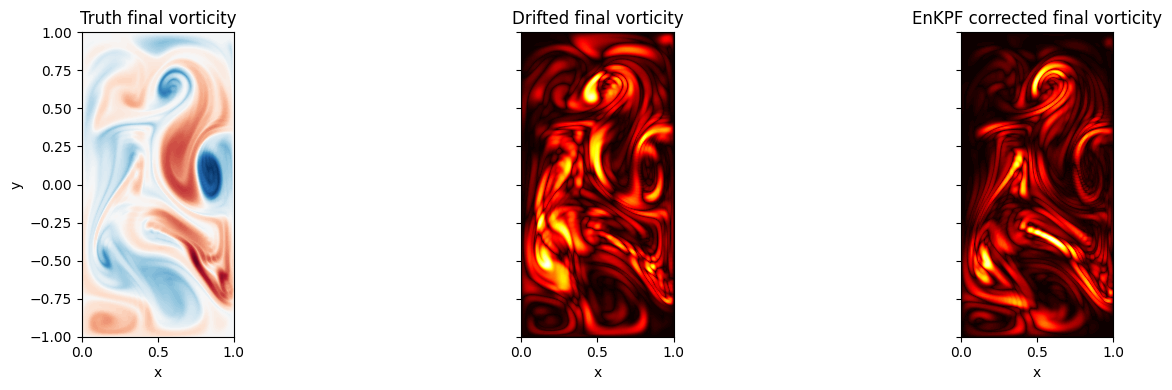

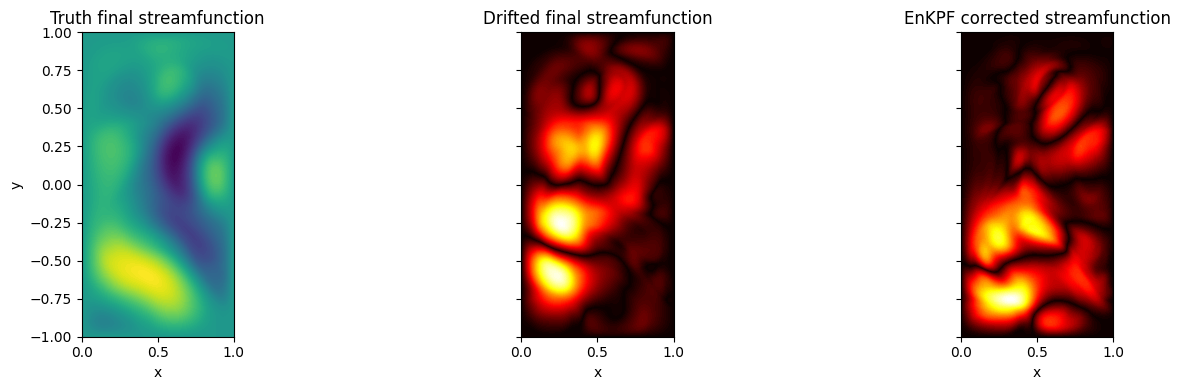

In [2]:
# 4. Final vorticity fields
fig4, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)

axes[0].contourf(X, Y, wen_truth, 100, cmap='RdBu_r')
axes[0].set_title("Truth final vorticity")
axes[0].set_aspect('equal')
axes[0].set_ylabel("y")
axes[0].set_xlabel("x")

axes[1].contourf(X, Y, np.abs(wen_truth-free_w), 100, cmap='hot')
axes[1].set_title("Drifted final vorticity")
axes[1].set_aspect('equal')
axes[1].set_xlabel("x")

axes[2].contourf(X, Y, np.abs(wen_truth-w_mean_final), 100, cmap='hot')
axes[2].set_title("EnKPF corrected final vorticity")
axes[2].set_aspect('equal')
axes[2].set_xlabel("x")

plt.tight_layout()

# 5. Final streamfunction fields
fig5, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)

axes[0].contourf(X, Y, sen_truth, 100, cmap='viridis')
axes[0].set_title("Truth final streamfunction")
axes[0].set_aspect('equal')
axes[0].set_ylabel("y")
axes[0].set_xlabel("x")

axes[1].contourf(X, Y, np.abs(sen_truth-free_s), 100, cmap='hot')
axes[1].set_title("Drifted final streamfunction")
axes[1].set_aspect('equal')
axes[1].set_xlabel("x")

axes[2].contourf(X, Y, np.abs(sen_truth-s_mean_final), 100, cmap='hot')
axes[2].set_title("EnKPF corrected streamfunction")
axes[2].set_aspect('equal')
axes[2].set_xlabel("x")

plt.tight_layout()